# Notebook 3 — Deploy & Invoke a SageMaker Endpoint

This notebook:
1. Creates a SageMaker **real-time inference endpoint** from the trained model
2. Runs predictions on sample images
3. Plots a confusion matrix on a 1,000-image subset
4. **Deletes the endpoint** when done (save money!)

> **Prerequisites:** `02_train_sagemaker.ipynb` must be completed.

In [ ]:
import os, sys, io, json
sys.path.insert(0, '../src')

import boto3, sagemaker
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv

load_dotenv('../.env')

REGION   = os.environ['AWS_REGION']
ROLE_ARN = os.environ['SAGEMAKER_ROLE_ARN']
BUCKET   = os.environ['S3_BUCKET']

session  = sagemaker.Session(boto_session=boto3.Session(region_name=REGION))
sm_rt    = boto3.client('sagemaker-runtime', region_name=REGION)

ENDPOINT_NAME = 'pytorch-workshop-endpoint'
print('Setup complete.')

## 1. Create the inference endpoint

We use `sagemaker.pytorch.PyTorchModel` which automatically serves `model_fn` / `predict_fn`.

In [10]:
from sagemaker.pytorch import PyTorchModel

# Point to the model artifact from Notebook 2
MODEL_S3_URI = f's3://{BUCKET}/training-output/model.tar.gz'

pytorch_model = PyTorchModel(
    model_data=MODEL_S3_URI,
    role=ROLE_ARN,
    entry_point='inference.py',
    source_dir='../src',
    framework_version='2.2',
    py_version='py310',
    sagemaker_session=session,
)

predictor = pytorch_model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.xlarge',
    endpoint_name=ENDPOINT_NAME,
)

print(f'Endpoint deployed: {ENDPOINT_NAME}')

------!Endpoint deployed: pytorch-workshop-endpoint


## 2. Predict on a single image

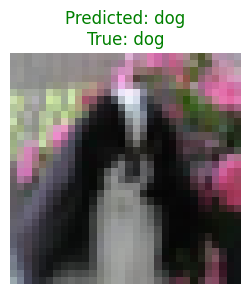

In [11]:
import torchvision, torch
from utils import get_transforms, CIFAR10_MEAN, CIFAR10_STD
from model import CIFAR10Net

CLASS_NAMES = CIFAR10Net.CLASS_NAMES

# Grab one image from the validation set
val_ds = torchvision.datasets.CIFAR10(
    root='../datasets', train=False, download=True,
    transform=get_transforms(train=False)
)
img_tensor, true_label = val_ds[42]

# Serialize as JSON
payload = json.dumps({'inputs': img_tensor.unsqueeze(0).tolist()})

response = sm_rt.invoke_endpoint(
    EndpointName=ENDPOINT_NAME,
    ContentType='application/json',
    Body=payload,
)
result = json.loads(response['Body'].read())
pred_idx = int(np.argmax(result['predictions'][0]))

# Show result
mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
std  = torch.tensor(CIFAR10_STD).view(3,1,1)
img_display = (img_tensor * std + mean).clamp(0,1).permute(1,2,0).numpy()

plt.figure(figsize=(3,3))
plt.imshow(img_display)
plt.title(f'Predicted: {CLASS_NAMES[pred_idx]}\nTrue: {CLASS_NAMES[true_label]}',
          color='green' if pred_idx == true_label else 'red')
plt.axis('off')
plt.show()

## 3. Batch evaluation on 1,000 samples

  0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy on 1000 samples: 85.90%


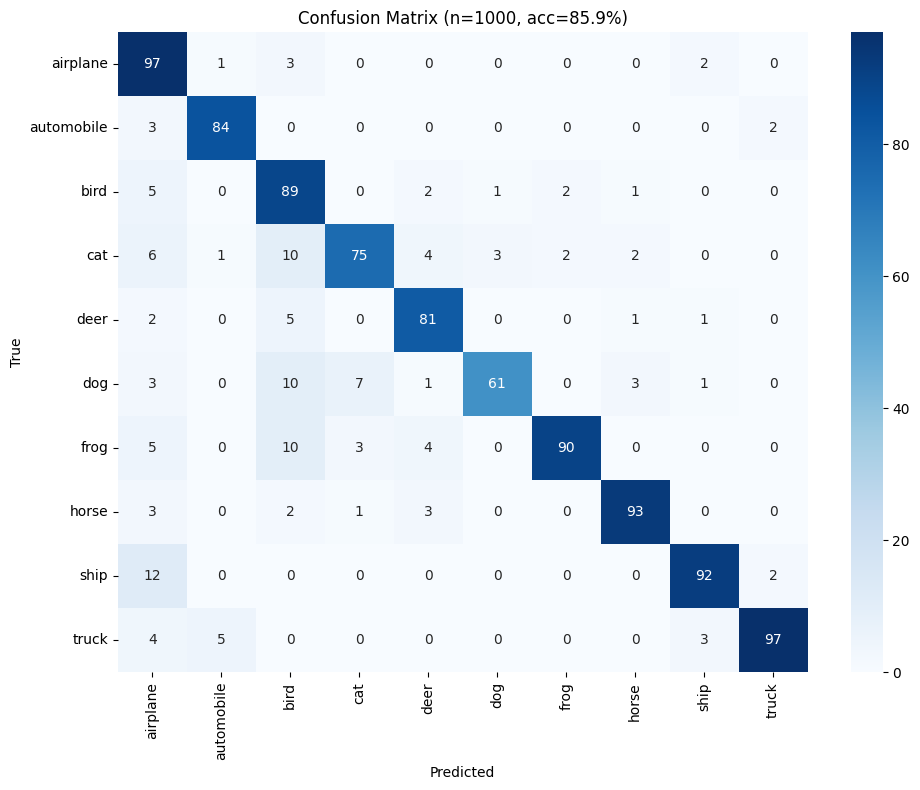

In [12]:
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

N = 1000
all_preds, all_labels = [], []

for idx in tqdm(range(N)):
    img, label = val_ds[idx]
    payload = json.dumps({'inputs': img.unsqueeze(0).tolist()})
    resp = sm_rt.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType='application/json',
        Body=payload,
    )
    result = json.loads(resp['Body'].read())
    all_preds.append(int(np.argmax(result['predictions'][0])))
    all_labels.append(label)

accuracy = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f'Accuracy on {N} samples: {accuracy:.2f}%')

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
ax.set_title(f'Confusion Matrix (n={N}, acc={accuracy:.1f}%)')
plt.tight_layout()
plt.show()

## 4. Delete the endpoint (important — avoid charges!)

In [ ]:
predictor.delete_endpoint()
print(f'Endpoint {ENDPOINT_NAME} deleted.')

---
**Workshop complete!** You have:
- Built a custom PyTorch CNN (`CIFAR10Net`)
- Trained it on a SageMaker GPU instance
- Deployed and queried a real-time inference endpoint
- Evaluated per-class accuracy with a confusion matrix

Run `scripts/cleanup_aws.py` to delete all remaining AWS resources.